In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import pickle

In [2]:
%pip install pandas numpy matplotlib seaborn scikit-learn pyarrow


Note: you may need to restart the kernel to use updated packages.


In [3]:
df=pd.read_parquet("job_table.parquet")
df.head()

,cores_alloc_layout,cores_allocated,cores_per_task,derived_ec,eligible_time,end_time,group_id,job_id,job_state,nodes,...,threads_per_core,time_limit,num_gpus_req,num_gpus_alloc,mem_req,mem_alloc,user_id,node_power_consumption,mem_power_consumption,cpu_power_consumption
0,"{900: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 1...","{900: 128, 915: 128, 902: 128, 901: 128, 904: ...",4,1:0,2020-05-31 22:09:29+00:00,2020-05-31 22:21:33+00:00,25200,2913594,CANCELLED,"[900, 901, 902, 903, 904, 905, 906, 907, 908, ...",...,NaN,270,64,64,475,3800,310,"[7970, 8450, 8460, 8470, 7440, 8470, 8460, 847...","[418, 724, 724, 678, 556, 654, 606, 600, 600, ...","[948, 1628, 1650, 1544, 1260, 1532, 1418, 1700..."
1,"{687: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 1...","{687: 128, 688: 128, 681: 128, 682: 128, 680: ...",4,1:0,2020-05-31 22:22:08+00:00,2020-05-31 22:41:25+00:00,25200,4063066,CANCELLED,"[680, 681, 682, 683, 684, 685, 686, 687, 688, ...",...,NaN,270,64,64,475,3800,310,"[7970, 8430, 7940, 8480, 7460, 8490, 6890, 848...","[720, 738, 736, 614, 720, 642, 632, 524, 598, ...","[1640, 1604, 1592, 1364, 1532, 1508, 1528, 147..."
2,"{687: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 1...","{687: 128, 688: 128, 681: 128, 682: 128, 680: ...",4,1:0,2020-05-31 22:41:38+00:00,2020-05-31 22:56:20+00:00,25200,5730196,CANCELLED,"[680, 681, 682, 683, 684, 685, 686, 687, 688, ...",...,NaN,270,64,64,475,3800,310,"[7950, 7970, 8500, 8480, 8470, 6900, 8460, 845...","[672, 720, 716, 630, 674, 474, 644, 606, 602, ...","[1654, 1600, 1606, 1438, 1506, 1108, 1496, 167..."
3,"{416: [0, 1, 2, 3, 4, 5, 6, 7]}",{416: 32},32,1:0,2020-05-31 23:26:23+00:00,2020-05-31 23:45:16+00:00,25200,3047960,FAILED,[416],...,NaN,30,4,4,59,59,379,"[860, 860, 860, 860, 860, 860, 860, 860, 860, ...","[38, 40, 46, 44, 48, 40, 44, 46, 42, 40, 40, 4...","[108, 182, 178, 182, 190, 174, 188, 186, 190, ..."
4,"{416: [0, 1, 2, 3, 4, 5, 6, 7]}",{416: 32},32,1:0,2020-05-31 23:08:01+00:00,2020-05-31 23:25:27+00:00,25200,5749077,FAILED,[416],...,NaN,30,4,4,59,59,379,"[860, 860, 860, 860, 860, 860, 860, 860, 860, ...","[36, 44, 42, 42, 44, 40, 44, 42, 50, 42, 42, 4...","[82, 182, 178, 180, 170, 168, 168, 192, 196, 1..."


In [4]:
df.job_state.value_counts()

job_state
COMPLETED        180310
FAILED            29840
CANCELLED         11218
TIMEOUT            8689
OUT_OF_MEMORY      1011
NODE_FAIL           170
Name: count, dtype: int64

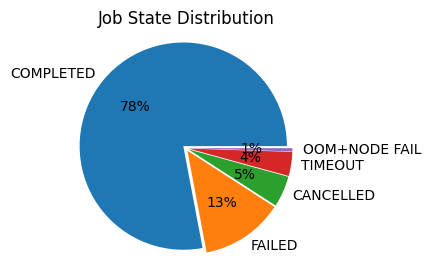

In [5]:
df["job_state"] = df["job_state"].replace("OUT_OF_MEMORY", "OOM+NODE FAIL")
df["job_state"] = df["job_state"].replace("NODE_FAIL", "OOM+NODE FAIL")

job_state_counts = df['job_state'].value_counts()

plt.figure(figsize=(3, 3))
plt.pie(job_state_counts, labels=job_state_counts.index, explode=[0.03]*(len(job_state_counts)), autopct='%1.0f%%')
plt.title("Job State Distribution")
plt.axis('equal')  
plt.show()

In [6]:
print(df.columns)

Index(['cores_alloc_layout', 'cores_allocated', 'cores_per_task', 'derived_ec',
       'eligible_time', 'end_time', 'group_id', 'job_id', 'job_state', 'nodes',
       'num_cores_req', 'num_cores_alloc', 'num_nodes_req', 'num_nodes_alloc',
       'num_tasks', 'partition', 'priority', 'qos', 'req_nodes', 'req_switch',
       'run_time', 'shared', 'start_time', 'state_reason', 'submit_time',
       'threads_per_core', 'time_limit', 'num_gpus_req', 'num_gpus_alloc',
       'mem_req', 'mem_alloc', 'user_id', 'node_power_consumption',
       'mem_power_consumption', 'cpu_power_consumption'],
      dtype='object')


/var/folders/lj/88mth58x7277_6kldjrctjvw0000gn/T/ipykernel_5520/2678707944.py:3: UserWarning: The palette list has more values (10) than needed (5), which may not be intended.
  sns.histplot(data=df, x = "run_time", hue = "job_state", multiple="dodge", kde = False, log_scale=False, palette=sns.color_palette("colorblind"), hue_order=["COMPLETED", "FAILED", "CANCELLED", "TIMEOUT", "OOM+NODE FAIL"],binwidth=100)


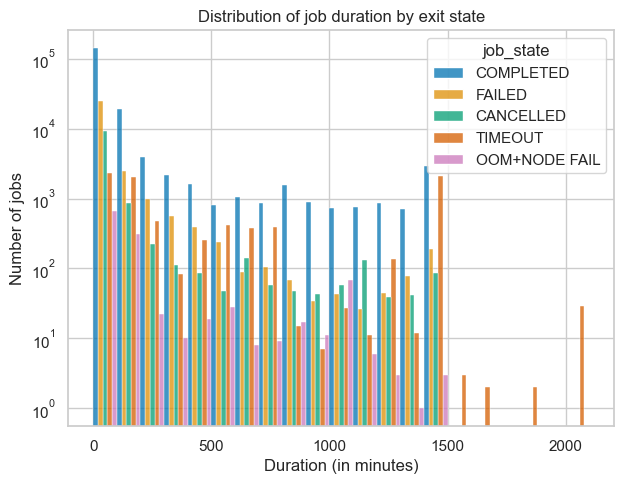

In [7]:
df.run_time = df.run_time.apply(lambda rt: round(int(rt/60), -2)).values
sns.set_theme(style="whitegrid")
sns.histplot(data=df, x = "run_time", hue = "job_state", multiple="dodge", kde = False, log_scale=False, palette=sns.color_palette("colorblind"), hue_order=["COMPLETED", "FAILED", "CANCELLED", "TIMEOUT", "OOM+NODE FAIL"],binwidth=100)
plt.xlabel("Duration (in minutes)")
plt.ylabel("Number of jobs")
plt.yscale("log")
plt.tight_layout()
plt.title("Distribution of job duration by exit state")
plt.show()  

partition column shows which partition each job is sent to
categorical, gives information about runtime, also qos.

In [8]:
df["submit_hour"]=pd.to_datetime(df["submit_time"]).dt.hour
df=df.drop(columns=["submit_time"])

In [9]:
Ys = df["run_time"]
Xs = df[["group_id", "user_id", "num_nodes_req", "num_cores_req", "req_switch", "mem_req", "num_gpus_req", "time_limit", "qos", "partition", "threads_per_core", "priority", "cores_per_task", "num_tasks"]]

In [10]:
categorical_columns = df.select_dtypes(include=["object", "category"]).columns.tolist()
print(categorical_columns)

['cores_alloc_layout', 'cores_allocated', 'derived_ec', 'job_state', 'nodes', 'partition', 'qos', 'req_nodes', 'shared', 'state_reason', 'node_power_consumption', 'mem_power_consumption', 'cpu_power_consumption']


In [11]:
categorical_cols = ["qos", "partition"]
numerical_cols = ["num_nodes_req", "num_cores_req", "mem_req", "num_gpus_req", "time_limit", "cores_per_task", "num_tasks", "group_id", "user_id", "req_switch", "threads_per_core", "priority"]

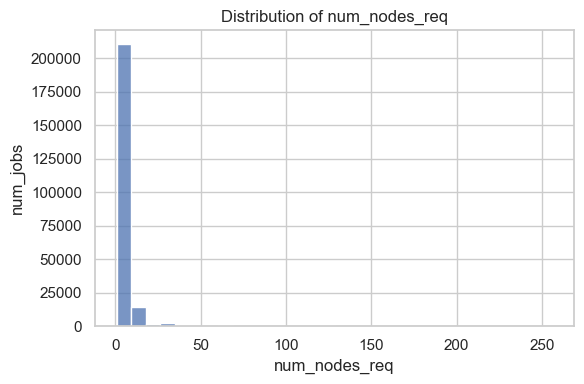

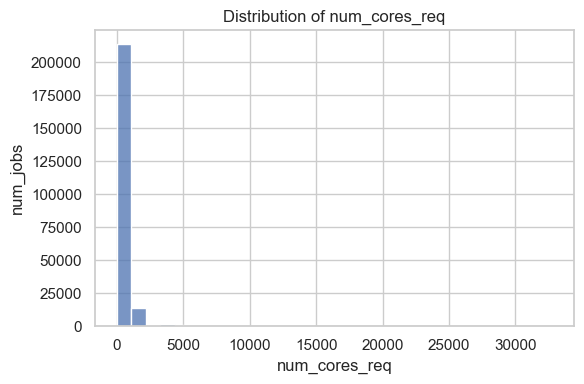

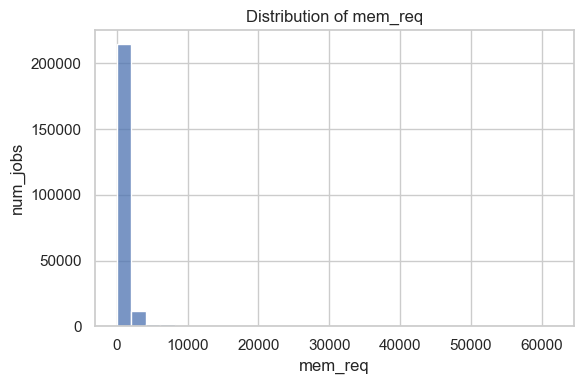

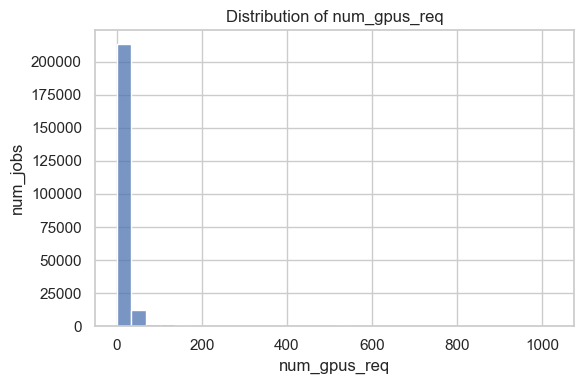

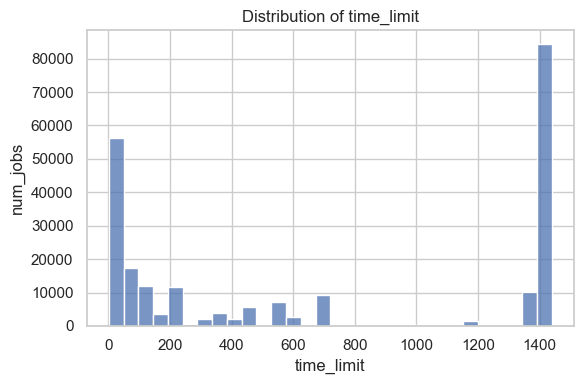

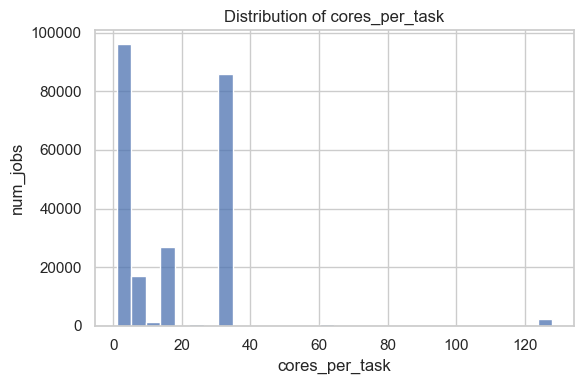

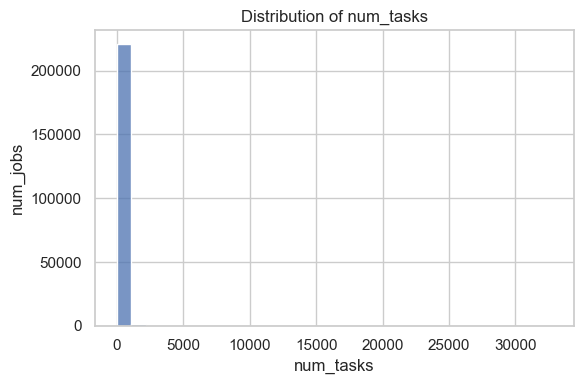

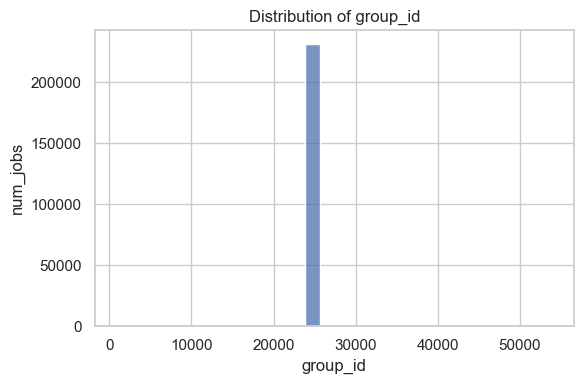

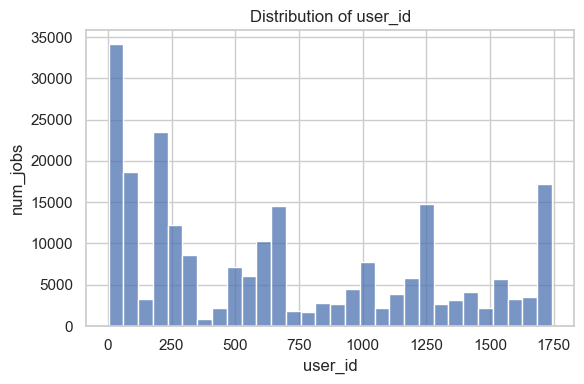

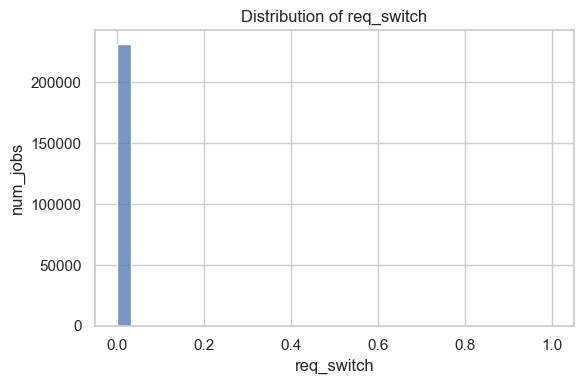

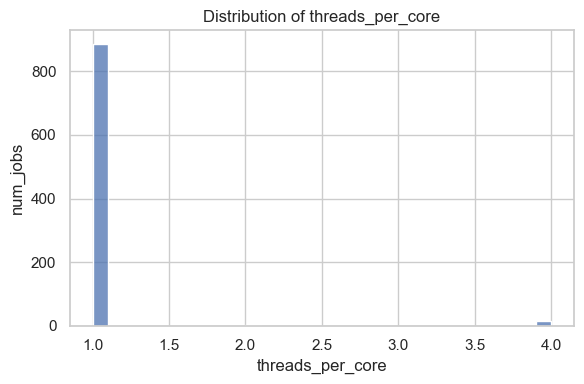

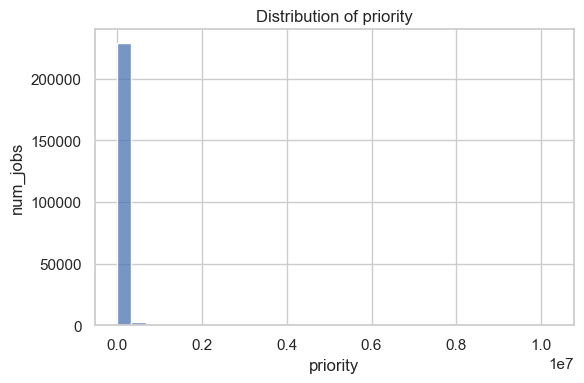

In [12]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(Xs[col], bins=30)
    plt.title("Distribution of " + col)
    plt.xlabel(col)
    plt.ylabel("num_jobs")
    plt.tight_layout()
    plt.show()

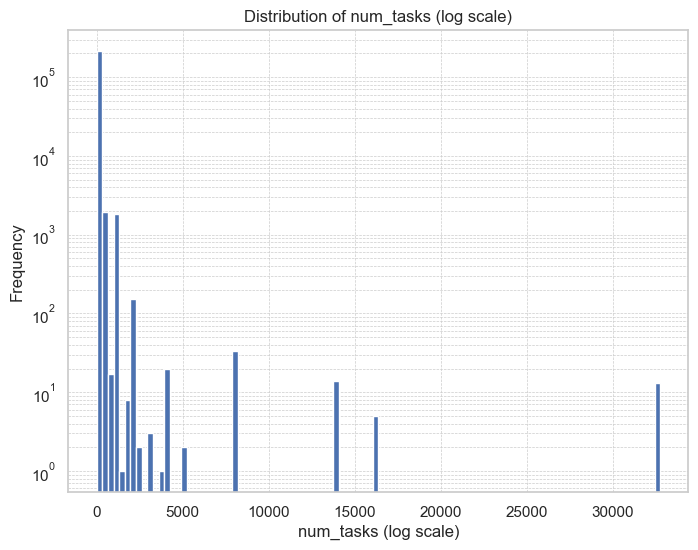

In [13]:
num_tasks = pd.to_numeric(df['num_tasks'], errors='coerce').dropna()
positive_values = num_tasks[num_tasks > 0]
plt.figure(figsize=(8, 6))
plt.hist(positive_values, bins=100)
plt.yscale('log')
plt.xlabel('num_tasks (log scale)')
plt.ylabel('Frequency')
plt.title('Distribution of num_tasks (log scale)')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()


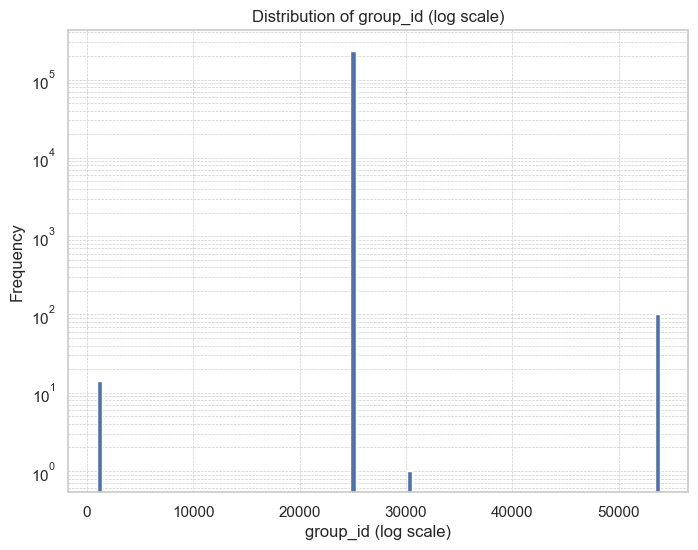

In [14]:
group_id = pd.to_numeric(df['group_id'], errors='coerce').dropna()
positive_values = group_id[group_id > 0]
plt.figure(figsize=(8, 6))
plt.hist(positive_values, bins=100)
plt.yscale('log')
plt.xlabel('group_id (log scale)')
plt.ylabel('Frequency')
plt.title('Distribution of group_id (log scale)')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()


In [15]:
print(df['group_id'].value_counts())

group_id
25200    231123
53482        90
915          14
53925        10
30227         1
Name: count, dtype: int64


In [16]:
print(df['req_switch'].value_counts())

req_switch
0    231225
1        13
Name: count, dtype: int64


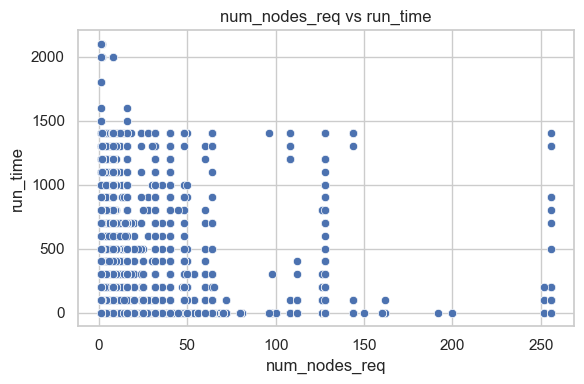

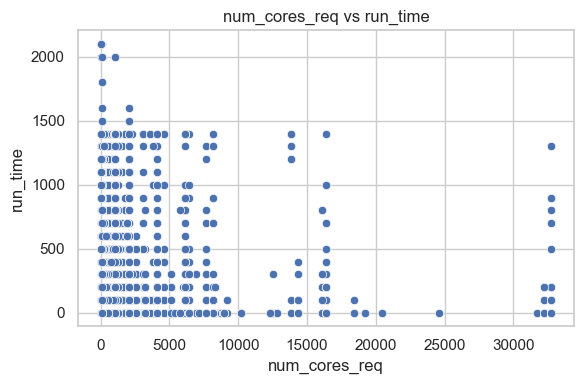

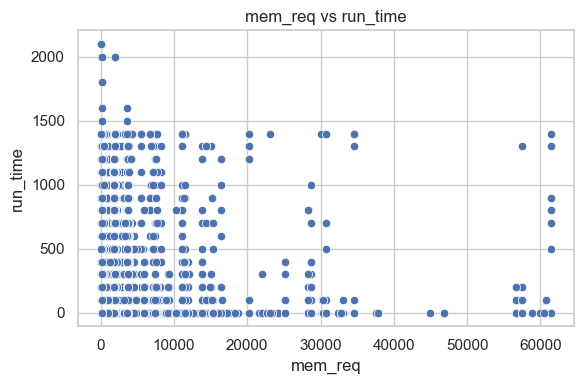

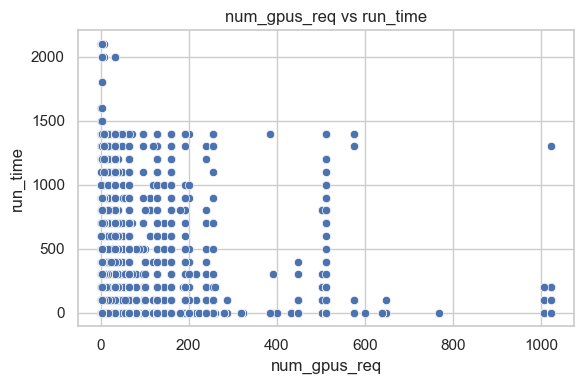

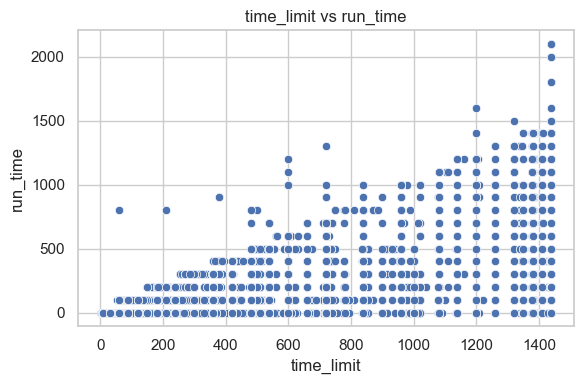

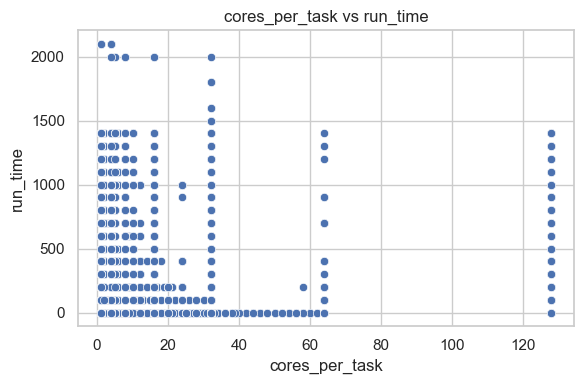

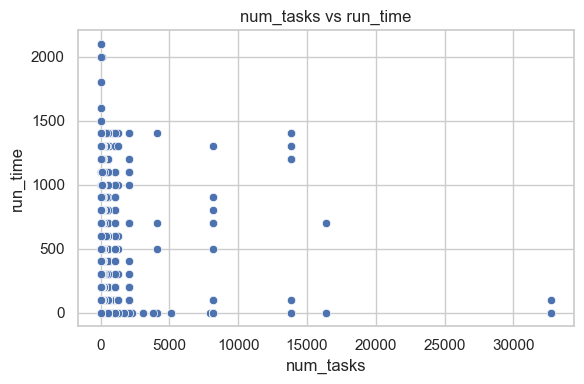

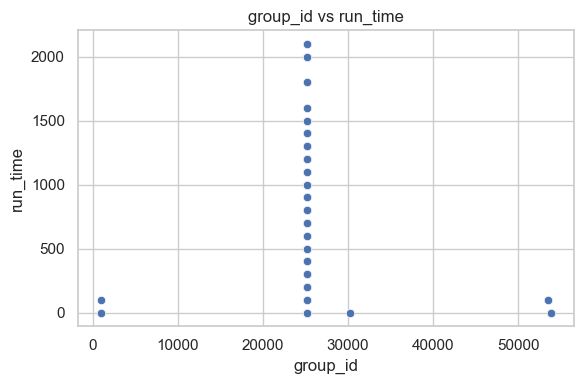

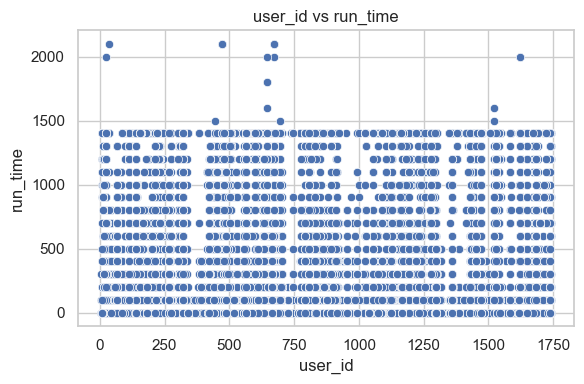

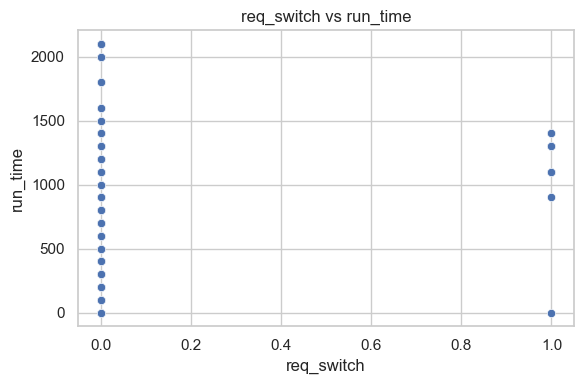

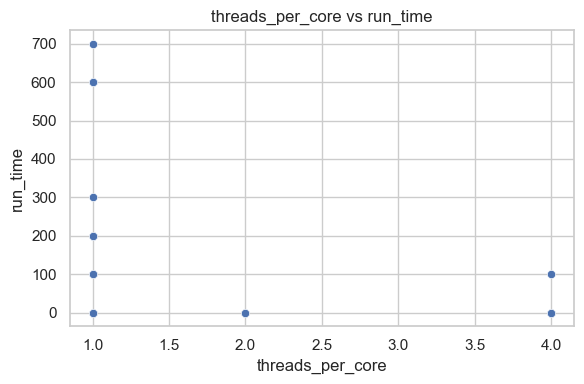

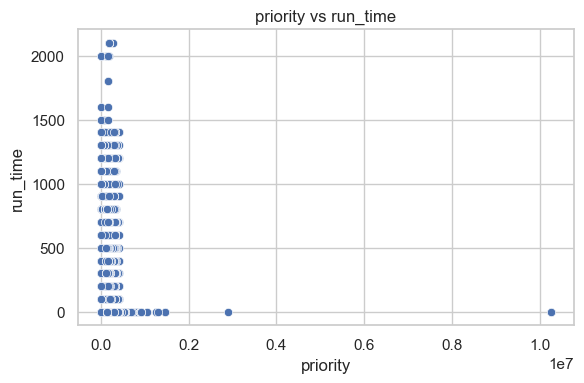

In [17]:
for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=Xs[col], y=Ys)
    plt.title(col + " vs run_time")
    plt.xlabel(col)
    plt.ylabel("run_time")
    plt.tight_layout()
    plt.show()

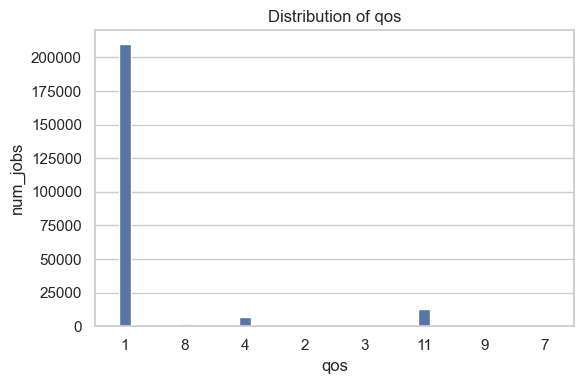

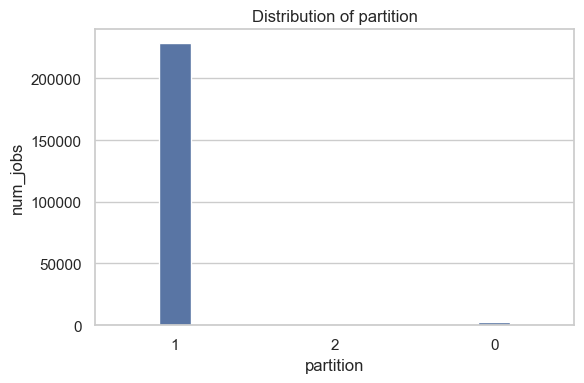

In [18]:
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=Xs[col], width=0.2)
    plt.title("Distribution of " + col)
    plt.xlabel(col)
    plt.ylabel("num_jobs")
    plt.tight_layout()
    plt.show()

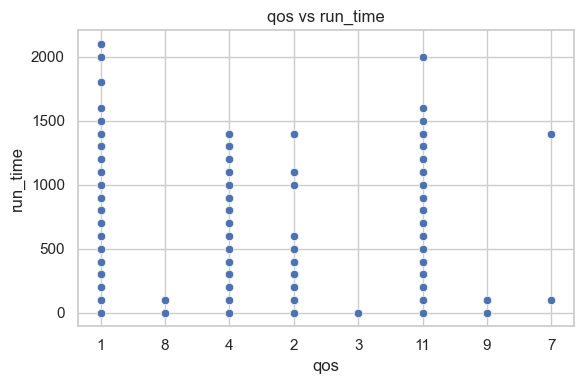

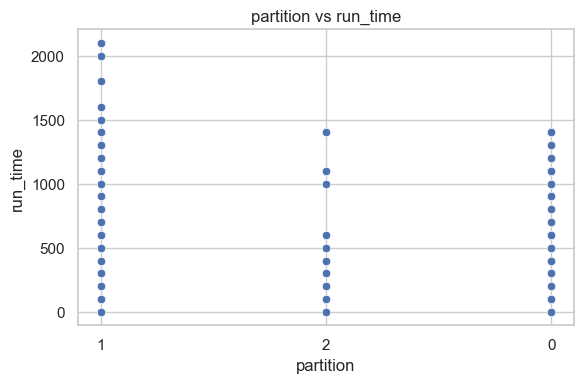

In [19]:
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=Xs[col], y=Ys)
    plt.title(col + " vs run_time")
    plt.xlabel(col)
    plt.ylabel("run_time")
    plt.tight_layout()
    plt.show()

In [20]:
Xs.loc[:, 'qos'] = Xs['qos'].astype(str)
Xs.loc[:, 'partition'] = Xs['partition'].astype(str)

In [21]:
df = df[df["run_time"] > 1]
df.to_parquet("job_table.parquet", index=False)

In [24]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(sparse_output=True, handle_unknown='ignore')
scaler = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
    ('num', scaler, numerical_cols),
    ('cat', encoder, categorical_cols)
], sparse_threshold=1.0)

In [25]:
print(Xs.head())

   group_id  user_id  num_nodes_req  num_cores_req  req_switch  mem_req  \
0     25200      310             16            256           0      475   
1     25200      310             16            256           0      475   
2     25200      310             16            256           0      475   
3     25200      379              1             32           0       59   
4     25200      379              1             32           0       59   

   num_gpus_req  time_limit qos partition  threads_per_core  priority  \
0            64         270   1         1               NaN    330603   
1            64         270   1         1               NaN     81394   
2            64         270   1         1               NaN     80615   
3             4          30   1         1               NaN    206885   
4             4          30   1         1               NaN    330339   

   cores_per_task  num_tasks  
0               4       64.0  
1               4       64.0  
2               4

In [26]:
Xs_transformed = preprocessor.fit_transform(Xs)

In [30]:
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + cat_feature_names.tolist()
Xs_processed_df = pd.DataFrame(
    Xs_transformed.toarray(),   
    columns=all_feature_names
)

In [31]:
Xs_processed_df.sample(5)

,num_nodes_req,num_cores_req,mem_req,num_gpus_req,time_limit,cores_per_task,num_tasks,group_id,user_id,req_switch,...,qos_11,qos_2,qos_3,qos_4,qos_7,qos_8,qos_9,partition_0,partition_1,partition_2
87968,-0.21781,-0.216622,-0.232218,-0.187871,-1.070599,-0.829650,-0.027876,-0.01746,1.822277,-0.007498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
47816,-0.14995,-0.168810,-0.099246,-0.116415,-0.644698,-0.041309,-0.100193,-0.01746,-0.629389,-0.007498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
121907,-0.21781,-0.261445,-0.276810,-0.187871,-1.070599,-0.885960,-0.112246,-0.01746,-0.851473,-0.007498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
84915,-0.21781,-0.216622,-0.232218,-0.187871,-1.070599,-0.829650,-0.027876,-0.01746,-1.115526,-0.007498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31698,-0.21781,-0.216622,-0.232218,-0.241462,1.153550,-0.829650,-0.027876,-0.01746,0.003637,-0.007498,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [32]:
Xs_processed_df[numerical_cols].describe()

,num_nodes_req,num_cores_req,mem_req,num_gpus_req,time_limit,cores_per_task,num_tasks,group_id,user_id,req_switch,threads_per_core,priority
count,2.312380e+05,2.312380e+05,2.312380e+05,2.312380e+05,2.312380e+05,2.312380e+05,2.217810e+05,2.312380e+05,2.312380e+05,2.312380e+05,9.040000e+02,2.312380e+05
mean,-7.128842e-18,-1.401186e-17,-1.634717e-17,-2.605715e-17,-8.652939e-17,-4.129812e-17,3.844564e-18,-2.283380e-15,-7.276335e-17,-3.333963e-18,8.903890e-17,-9.095419e-18
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000554e+00,1.000002e+00
min,-2.178103e-01,-2.636865e-01,-2.796223e-01,-2.593264e-01,-1.116343e+00,-8.859596e-01,-1.242987e-01,-3.927375e+01,-1.164489e+00,-7.498153e-03,-1.436223e-01,-1.769309e+00
25%,-2.178103e-01,-2.465040e-01,-2.462789e-01,-1.878705e-01,-1.023276e+00,-8.859596e-01,-1.122459e-01,-1.746009e-02,-8.514732e-01,-7.498153e-03,-1.436223e-01,-8.973973e-01
50%,-2.178103e-01,-1.688096e-01,-1.856179e-01,-1.878705e-01,-2.661193e-01,-4.130946e-02,-1.122459e-01,-1.746009e-02,-1.834728e-01,-7.498153e-03,-1.436223e-01,-5.332645e-02
75%,-1.499498e-01,-1.688096e-01,-1.832076e-01,-1.878705e-01,1.153550e+00,8.596506e-01,-2.787611e-02,-1.746009e-02,9.374388e-01,-7.498153e-03,-1.436223e-01,7.648966e-01
max,1.708662e+01,2.421530e+01,2.442666e+01,1.803338e+01,1.153550e+00,6.265411e+00,9.861242e+01,4.641601e+01,1.878235e+00,1.333662e+02,7.346833e+00,9.699427e+01


In [33]:
num_df = Xs_processed_df[numerical_cols]

means = num_df.mean()
vars_  = num_df.var(ddof=0)  

print("Means:\n", means)
print("Variances:\n", vars_)

Means:
 num_nodes_req      -7.128842e-18
num_cores_req      -1.401186e-17
mem_req            -1.634717e-17
num_gpus_req       -2.605715e-17
time_limit         -8.652939e-17
cores_per_task     -4.129812e-17
num_tasks           3.844564e-18
group_id           -2.283380e-15
user_id            -7.276335e-17
req_switch         -3.333963e-18
threads_per_core    8.903890e-17
priority           -9.095419e-18
dtype: float64
Variances:
 num_nodes_req       1.0
num_cores_req       1.0
mem_req             1.0
num_gpus_req        1.0
time_limit          1.0
cores_per_task      1.0
num_tasks           1.0
group_id            1.0
user_id             1.0
req_switch          1.0
threads_per_core    1.0
priority            1.0
dtype: float64


In [34]:
with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(preprocessor, f)

In [35]:
Xs_processed_df.to_parquet("Xs.parquet", index=False)
Ys.to_frame(name="run_time").to_parquet("Ys.parquet", index=False)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(Xs_processed_df, Ys, test_size=0.1, shuffle= True, random_state=42)

In [29]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

rf = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
long_indices = y_test > 1

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAPE: ", mean_absolute_percentage_error(y_test[long_indices], y_pred_rf[long_indices]))


Random Forest Results
MAE: 46.03591312959828
MSE: 21509.32038962719
RMSE: 146.66056180728066
MAPE:  0.37419203701187265


In [30]:
print(X_train.isnull().sum())

num_nodes_req            0
num_cores_req            0
mem_req                  0
num_gpus_req             0
time_limit               0
cores_per_task           0
num_tasks             8491
group_id                 0
user_id                  0
req_switch               0
threads_per_core    207299
priority                 0
qos_1                    0
qos_11                   0
qos_2                    0
qos_3                    0
qos_4                    0
qos_7                    0
qos_8                    0
qos_9                    0
partition_0              0
partition_1              0
partition_2              0
dtype: int64


In [31]:
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

In [32]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

gb = GradientBoostingRegressor(
    n_estimators=200,    
    learning_rate=0.2,   
    max_depth=7,        
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
long_indices = y_test > 0

print("Gradient Boost Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("MAPE: ", mean_absolute_percentage_error(y_test[long_indices], y_pred_gb[long_indices]))

Gradient Boost Results:
MAE: 59.74316467820631
MSE: 24215.623812447135
RMSE: 155.61370059364032
MAPE:  0.441326883719311


In [33]:
print("Run Time Mean:", Ys.mean())
print("Run Time Median:", Ys.median())

Run Time Mean: 96.55679429851494
Run Time Median: 0.0


In [34]:
%pip install optuna

Note: you may need to restart the kernel to use updated packages.


In [35]:
import torch
import torch.nn as nn
import copy
import torch.optim as optim
import tqdm
import optuna
from sklearn.model_selection import train_test_split
print(torch.__version__)

2.2.2


In [36]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

In [37]:
scaler = StandardScaler()
scaler.fit(X_train_tensor.numpy())  

,copy,True
,with_mean,True
,with_std,True


In [38]:
def objective(trial):
    hidden1 = trial.suggest_int("hidden1", 64, 256)
    hidden2 = trial.suggest_int("hidden2", 32, 128)
    hidden3 = trial.suggest_int("hidden3", 16, 64)

    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
    n_epochs = trial.suggest_int("n_epochs", 50, 200)

    model = nn.Sequential(
        nn.Linear(X_train_tensor.shape[1], hidden1),
        nn.ReLU(),
        nn.Linear(hidden1, hidden2),
        nn.ReLU(),
        nn.Linear(hidden2, hidden3),
        nn.ReLU(),
        nn.Linear(hidden3, 1)
    )

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    batch_start = torch.arange(0, len(X_train_tensor), batch_size)

    best_mse = np.inf
    best_weights = None

    for epoch in range(n_epochs):
        model.train()
        for start in batch_start:
            X_batch = X_train_tensor[start:start+batch_size]
            y_batch = y_train_tensor[start:start+batch_size]

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            y_pred = model(X_test_tensor)
            mse = loss_fn(y_pred, y_test_tensor).item()
            if mse < best_mse:
                best_mse = mse
                best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor).numpy()
        y_true = y_test_tensor.numpy()
        mape = mean_absolute_percentage_error(y_true, y_pred)

    return mape


In [40]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30, timeout=600)

[I 2025-07-29 23:02:28,370] A new study created in memory with name: no-name-40d13a97-da9e-4654-b22d-e5e0d1fe9e76
[I 2025-07-29 23:05:21,830] Trial 0 finished with value: 1.325610560347177e+17 and parameters: {'hidden1': 216, 'hidden2': 86, 'hidden3': 23, 'lr': 0.004972963423767816, 'batch_size': 128, 'n_epochs': 62}. Best is trial 0 with value: 1.325610560347177e+17.
[I 2025-07-29 23:11:58,681] Trial 1 finished with value: 1.7513655144389018e+17 and parameters: {'hidden1': 242, 'hidden2': 127, 'hidden3': 58, 'lr': 0.0006780471130544108, 'batch_size': 64, 'n_epochs': 78}. Best is trial 0 with value: 1.325610560347177e+17.
[I 2025-07-29 23:17:26,333] Trial 2 finished with value: 1.6237170248174797e+17 and parameters: {'hidden1': 127, 'hidden2': 115, 'hidden3': 63, 'lr': 0.0005416063875362661, 'batch_size': 64, 'n_epochs': 73}. Best is trial 0 with value: 1.325610560347177e+17.


In [39]:
model = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 216),  
    nn.ReLU(),
    nn.Linear(216, 86), 
    nn.ReLU(),              
    nn.Linear(86, 23),                
    nn.ReLU(),
    nn.Linear(23, 1)             
)

In [40]:
loss_fn = nn.MSELoss()  
optimizer = optim.Adam(model.parameters(), lr=0.004972963423767816) 
n_epochs = 62  
batch_size = 128  
batch_start = torch.arange(0, len(X_train_tensor), batch_size)

In [41]:
best_mse = np.inf  
best_weights = None
history = []

In [42]:
for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train_tensor[start:start+batch_size]
            y_batch = y_train_tensor[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test_tensor)
    mse = loss_fn(y_pred, y_test_tensor)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

MSE: 37543.07
RMSE: 193.76


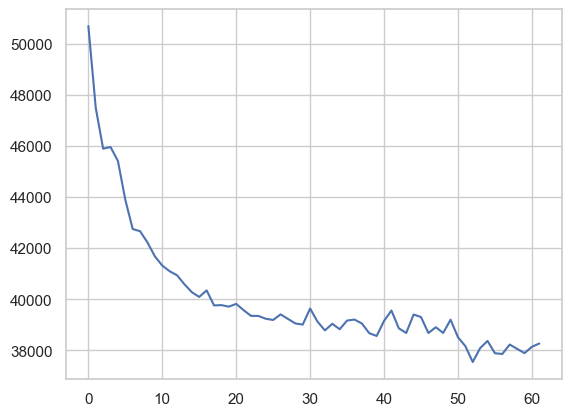

 MAPE: 0.5749
[-0.21781029 -0.24052755 -0.25592035 -0.18787052  1.15354997  0.85965064
 -0.12429869 -0.01746009 -0.91967221 -0.00749815 -0.05945988 -0.04122111
  1.          0.          0.          0.          0.          0.
  0.          0.          0.          1.          0.        ] -> [129.28322] (expected 0)
[-0.14994976 -0.07318562 -0.09924636 -0.11641463 -0.92863164  0.85965064
 -0.10019304 -0.01746009 -0.87595491 -0.00749815 -0.05945988  1.41033192
  1.          0.          0.          0.          0.          0.
  0.          0.          1.          0.          0.        ] -> [3.6998715] (expected 0)
[-0.21781029 -0.24650405 -0.24627887 -0.2593264   1.15354997 -0.88595955
 -0.05198176 -0.01746009  0.99864299 -0.00749815 -0.05945988  1.05446178
  1.          0.          0.          0.          0.          0.
  0.          0.          0.          1.          0.        ] -> [3.6998715] (expected 0)
[-0.14994976 -0.07318562 -0.08679279 -0.2593264  -1.07217598 -0.04130946
 -0.076087

In [44]:
if best_weights is not None:
    model.load_state_dict(best_weights)
else:
    print("Best weights not found!")
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.show()
 
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).numpy()
    y_true = y_test_tensor.numpy()
    long_indices = y_true[:, 0] > 1
    mape = mean_absolute_percentage_error(y_true[long_indices], y_pred[long_indices])
    print(" MAPE: %.4f" % mape)
    # Test out inference with 5 samples
    for i in range(5):
        X_sample = X_test.iloc[i:i+1].to_numpy()
        X_sample = scaler.transform(X_sample)
        X_sample = torch.tensor(X_sample, dtype=torch.float32)
        y_pred = model(X_sample)
        print(f"{X_test.iloc[i].values} -> {y_pred[0].numpy()} (expected {y_test.iloc[i]})")
       

In [46]:
selected_features=["user_id", "num_nodes_req", "num_cores_req", "time_limit", "partition", "priority"]
X = df[selected_features]
numerical_columns=["user_id", "num_nodes_req", "num_cores_req", "time_limit", "priority"]
categorical_columns=["partition"]

In [47]:
X.loc[:, 'partition'] = X['partition'].astype(str)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
scaler = StandardScaler()

preprocessor = ColumnTransformer(transformers=[
    ('num', scaler, numerical_columns),
    ('cat', encoder, categorical_columns)
])

In [48]:
X_transformed = preprocessor.fit_transform(X)
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_columns)
all_feature_names = numerical_columns + cat_feature_names.tolist()
X_processed_df = pd.DataFrame(X_transformed, columns=all_feature_names)

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_processed_df, Ys, test_size=0.1, shuffle= True, random_state=42)

In [50]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

rf = RandomForestRegressor(n_estimators=200, max_depth=20, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
long_indices = y_test > 1

print("Random Forest Results")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("MAPE: ", mean_absolute_percentage_error(y_test[long_indices], y_pred_rf[long_indices]))

Random Forest Results
MAE: 48.05264841749398
MSE: 22393.017183670265
RMSE: 149.64296570059773
MAPE:  0.3896412059275351


In [51]:
X_train = X_train.fillna(X_train.mean())
X_test = X_test.fillna(X_test.mean())

In [52]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

gb = GradientBoostingRegressor(
    n_estimators=200,    
    learning_rate=0.2,   
    max_depth=7,        
    random_state=42
)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
long_indices = y_test > 0

print("Gradient Boost Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("MSE:", mean_squared_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("MAPE: ", mean_absolute_percentage_error(y_test[long_indices], y_pred_gb[long_indices]))

Gradient Boost Results:
MAE: 61.223227298216
MSE: 25234.72765799351
RMSE: 158.85442284681125
MAPE:  0.4484404696204512


In [53]:
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)

X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

In [54]:
scaler = StandardScaler()
scaler.fit(X_train_tensor.numpy())  

,copy,True
,with_mean,True
,with_std,True


In [59]:
model = nn.Sequential(
    nn.Linear(X_train_tensor.shape[1], 216),  
    nn.ReLU(),
    nn.Linear(216, 86), 
    nn.ReLU(),              
    nn.Linear(86, 23),                
    nn.ReLU(),
    nn.Linear(23, 1)             
)

In [60]:
loss_fn = nn.MSELoss()  
optimizer = optim.Adam(model.parameters(), lr=0.004972963423767816) 
n_epochs = 62  
batch_size = 128  
batch_start = torch.arange(0, len(X_train_tensor), batch_size)

In [61]:
best_mse = np.inf  
best_weights = None
history = []

In [62]:
for epoch in range(n_epochs):
    model.train()
    with tqdm.tqdm(batch_start, unit="batch", mininterval=0, disable=True) as bar:
        bar.set_description(f"Epoch {epoch}")
        for start in bar:
            # take a batch
            X_batch = X_train_tensor[start:start+batch_size]
            y_batch = y_train_tensor[start:start+batch_size]
            # forward pass
            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)
            # backward pass
            optimizer.zero_grad()
            loss.backward()
            # update weights
            optimizer.step()
            # print progress
            bar.set_postfix(mse=float(loss))
    # evaluate accuracy at end of each epoch
    model.eval()
    y_pred = model(X_test_tensor)
    mse = loss_fn(y_pred, y_test_tensor)
    mse = float(mse)
    history.append(mse)
    if mse < best_mse:
        best_mse = mse
        best_weights = copy.deepcopy(model.state_dict())

MSE: 38407.73
RMSE: 195.98


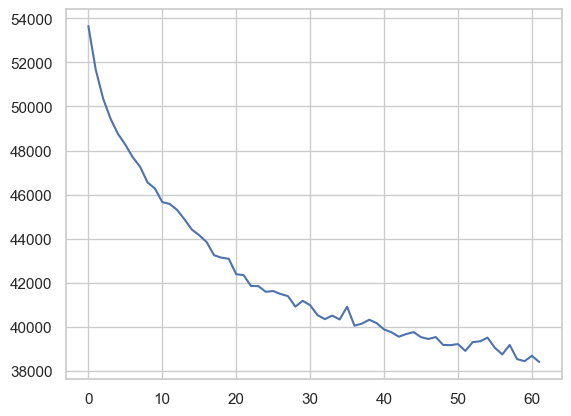

 MAPE: 0.5606
[-0.91967221 -0.21781029 -0.24052755  1.15354997 -0.04122111  0.
  1.          0.        ] -> [5.805525] (expected 0)
[-0.87595491 -0.14994976 -0.07318562 -0.92863164  1.41033192  1.
  0.          0.        ] -> [200.8087] (expected 0)
[ 0.99864299 -0.21781029 -0.24650405  1.15354997  1.05446178  0.
  1.          0.        ] -> [534.505] (expected 0)
[ 0.57371082 -0.14994976 -0.07318562 -1.07217598 -0.99078276  0.
  1.          0.        ] -> [-3.7049665] (expected 0)
[-0.18347285 -0.21781029 -0.26368648  1.15354997 -0.92820478  0.
  1.          0.        ] -> [663.1625] (expected 0)


In [63]:
if best_weights is not None:
    model.load_state_dict(best_weights)
else:
    print("Best weights not found!")
print("MSE: %.2f" % best_mse)
print("RMSE: %.2f" % np.sqrt(best_mse))
plt.plot(history)
plt.show()
 
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor).numpy()
    y_true = y_test_tensor.numpy()
    long_indices = y_true[:, 0] > 1
    mape = mean_absolute_percentage_error(y_true[long_indices], y_pred[long_indices])
    print(" MAPE: %.4f" % mape)
    # Test out inference with 5 samples
    for i in range(5):
        X_sample = X_test.iloc[i:i+1].to_numpy()
        X_sample = scaler.transform(X_sample)
        X_sample = torch.tensor(X_sample, dtype=torch.float32)
        y_pred = model(X_sample)
        print(f"{X_test.iloc[i].values} -> {y_pred[0].numpy()} (expected {y_test.iloc[i]})")
       